# All to all network Simulations

We simulate the whole network as an array and we reset it to the initial configuration following a Poisson process

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
from IPython.display import clear_output
import imageio.v2 as imageio
from tqdm import tqdm

from importlib import reload
from voter_model import solution as sol

sol = reload(sol)

In [3]:
@njit
def voter_model_evolution(N, t, r, m0):
    '''Takes:
    N: number of agents
    t: time in MC steps
    r: resetting rate per MC step
    m0: starting magnetisation
    
        Returns:
    config: The config at time t
    res: number of resets'''
    
    # Initialize
    n = int(N*(m0+1)/2)  
    n_ini = n
    time = 0.0
    res = 0

    while time < t:
        la = r + 2* ( n*(N-n)/(N-1) )
        dt = -np.log(np.random.random()) / la
        
        # Check if this step exceeds our simulation duration
        if time + dt > t:
            # We spend the remainder of the time in the current state 'n'
            break
            
        time += dt

        if np.random.random() < r/la:
            n = n_ini
            res += 1
        else:
            if np.random.random() < 0.5:
                n += 1
            else:
                n += -1
    
    return(2*n/N-1, res)

## Check Poisson

In [3]:
@njit
def check_poisson(N, T, r, div, samples):
    '''Checks if the resetting is a poisson process.
    Takes the same arguments as the simulation plus:
    
    div: number of different times we sample
    samples: number of samples per time
    '''
    
    res = np.zeros(div)

    ts = np.linspace(0, T, div)

    for i in range(div):
        t = ts[i]

        total = 0.0
        for _ in range(samples):
            _, resets = voter_model_evolution(N, int(t), r) #Calculate resets up to time t
            total += resets

        res[i] = total / samples

    return res

Text(0, 0.5, 'Resets')

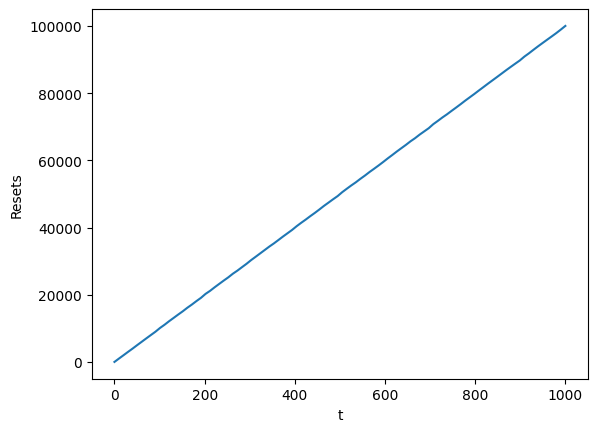

In [4]:
plt.plot(np.linspace(0, 1000, 100), check_poisson(1000, 1000, 0.1, 100, 50))
plt.xlabel("t")
plt.ylabel("Resets")

## Distribution of Magnetisation

In [4]:
@njit
def dist(N, t, r, m0, samples):
    '''Returns the magnetisation at time t for some samples'''
    res = np.zeros(samples)

    for i in range(samples):
        res[i] = voter_model_evolution(N, t, r, m0)[0]
    
    return res

In [ ]:
plt.hist(dist(1000, 1000, 0.01, 0.66, 50000), bins = 50)

# Compare 

In [18]:
N = 1000
r = 0.1
m0 = 0
d = dist(N, 1000, r, m0, 20000)

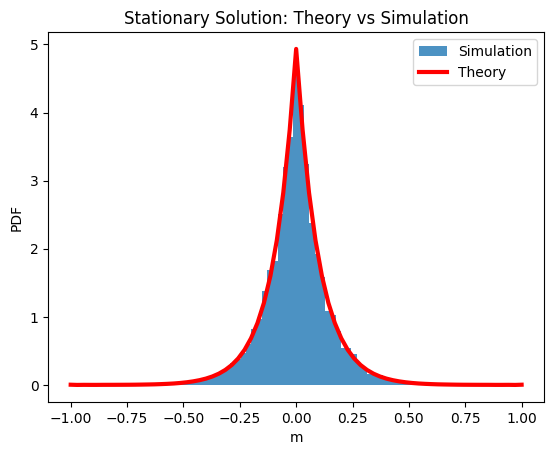

In [28]:
bins = 71

plt.title("Stationary Solution: Theory vs Simulation")
plt.xlabel("m")
plt.ylabel("PDF")


a = plt.hist(d, bins = bins, density=True, label = "Simulation", alpha = 0.8)
plt.plot(np.linspace(-1,1,bins), sol.sol(N,r,m0,bins), color = "r", label = "Theory", lw = 3)

plt.legend()

plt.savefig("../figures/theo_sim_del_2.pdf")

## Multicheck

m0: 0.9 r: 1 N: 1000


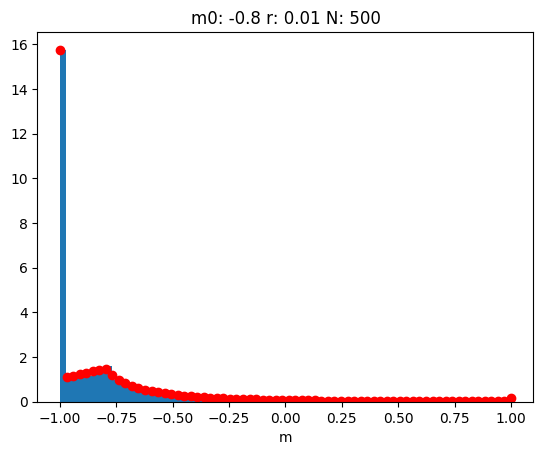

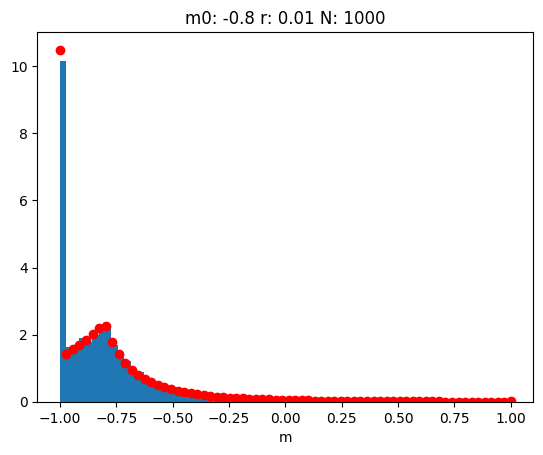

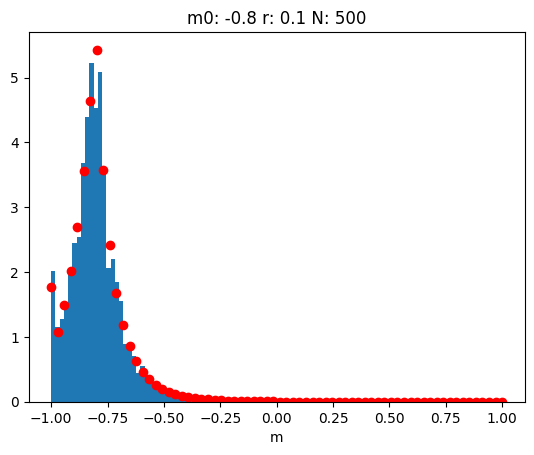

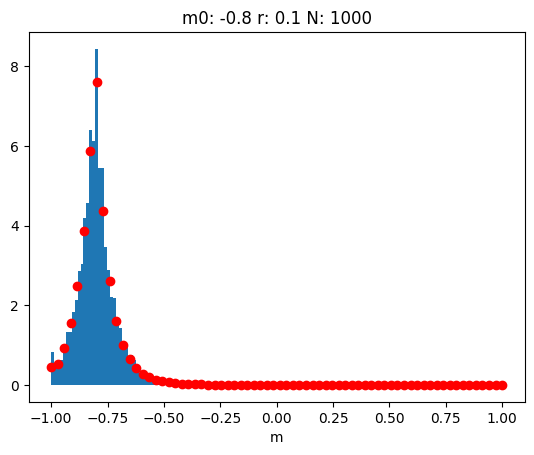

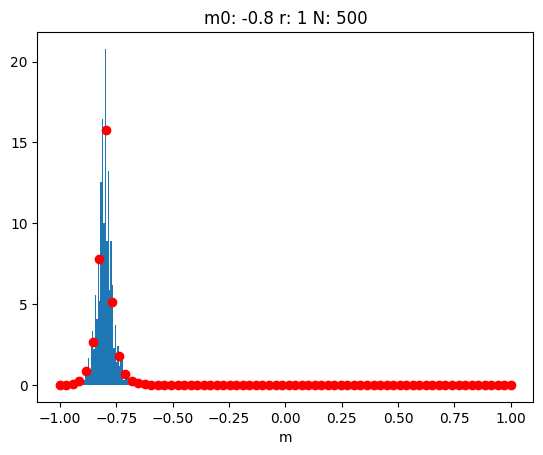

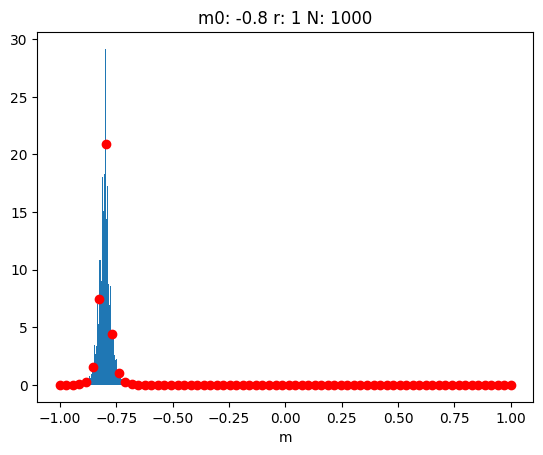

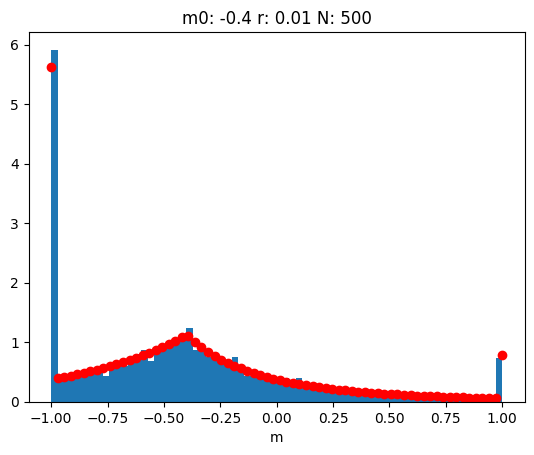

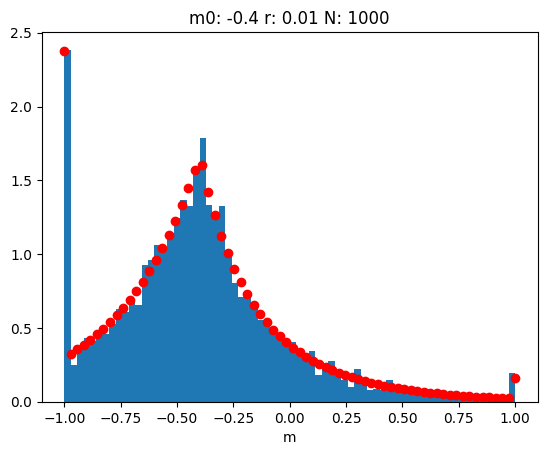

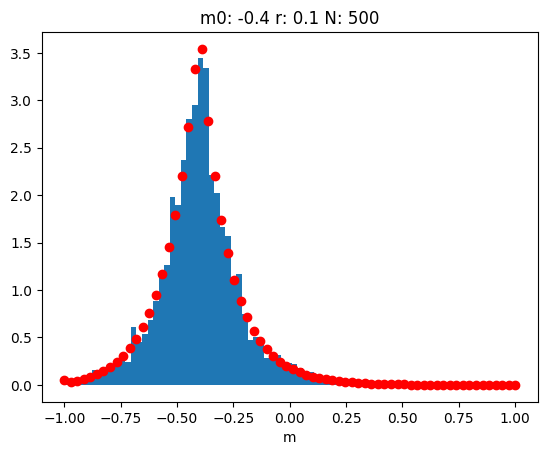

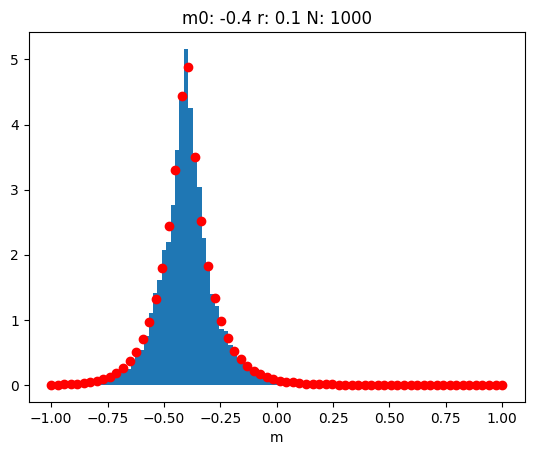

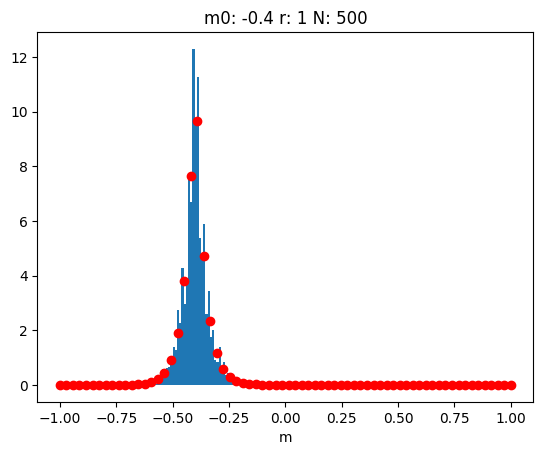

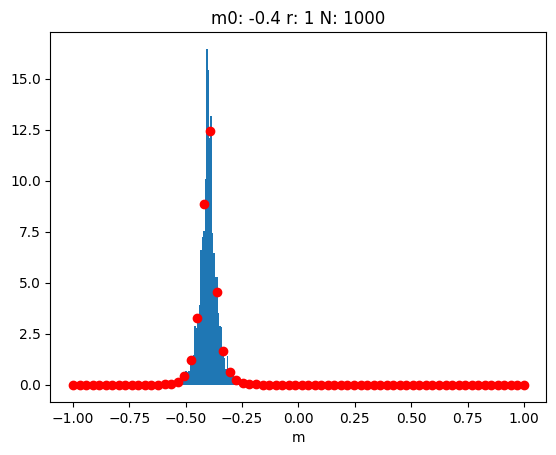

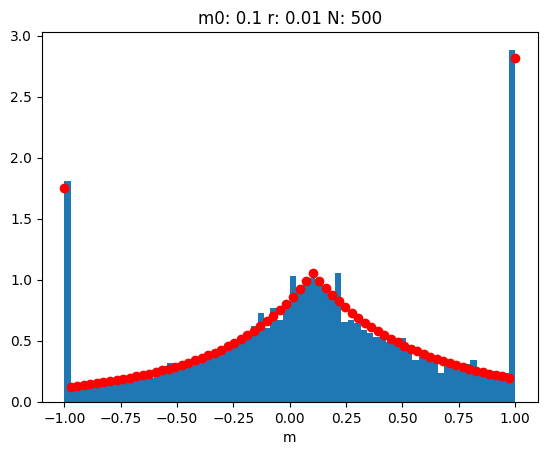

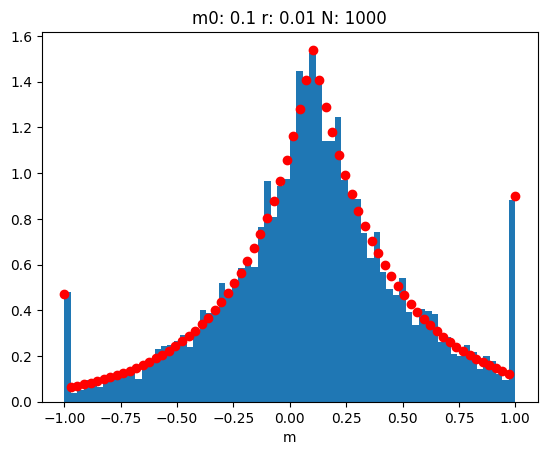

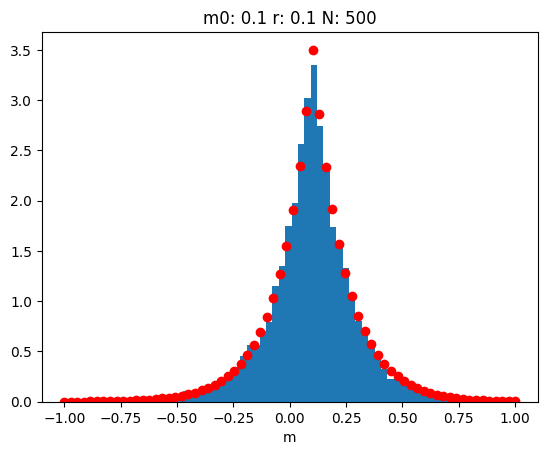

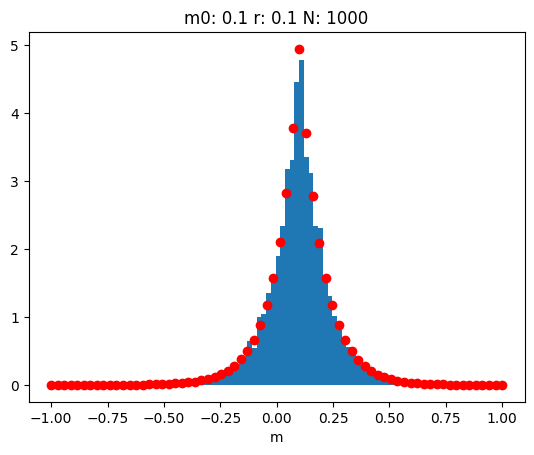

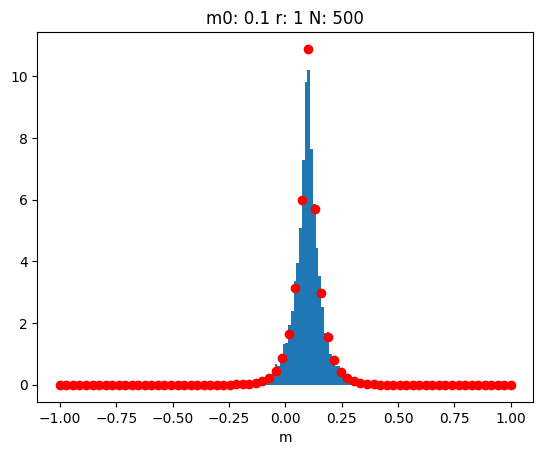

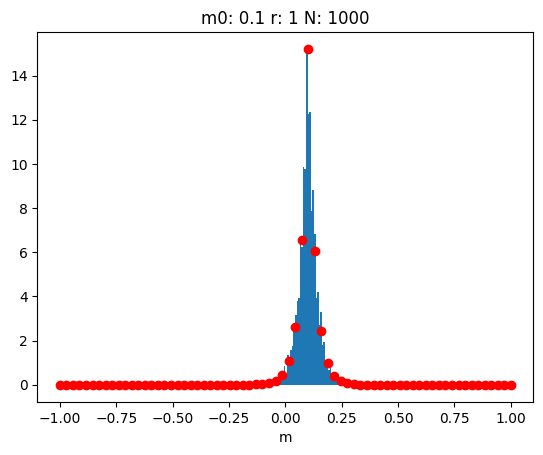

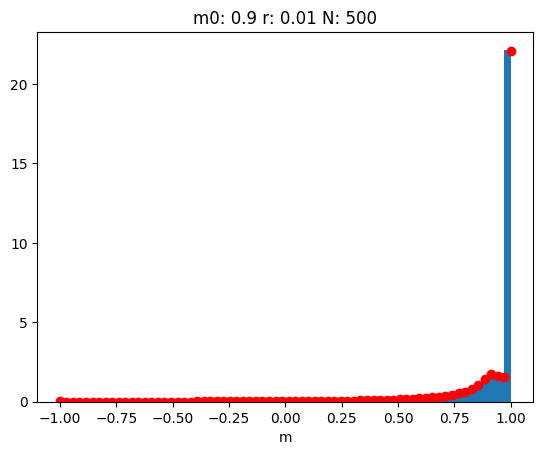

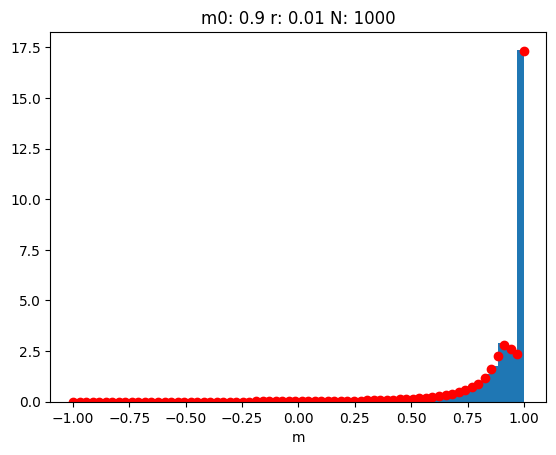

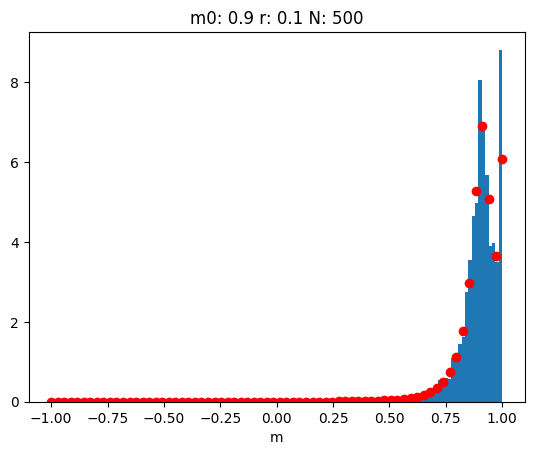

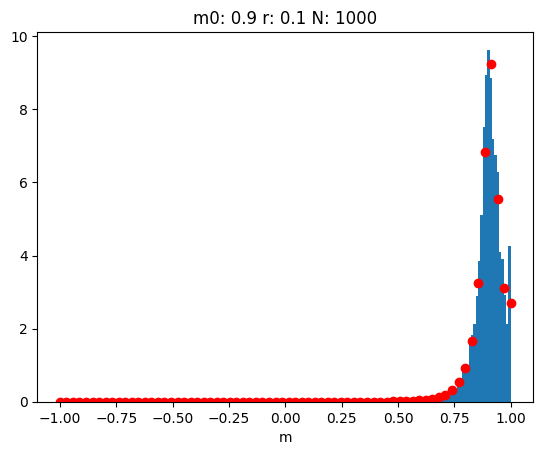

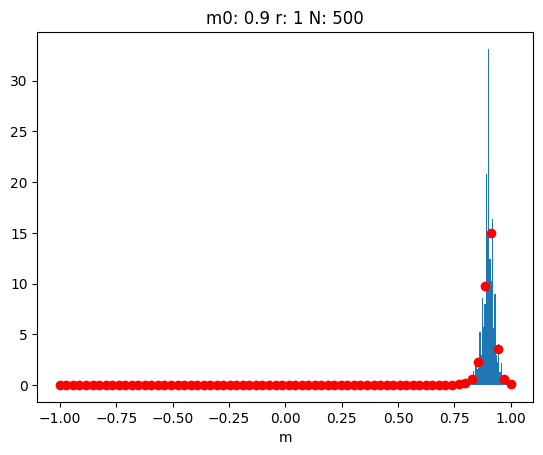

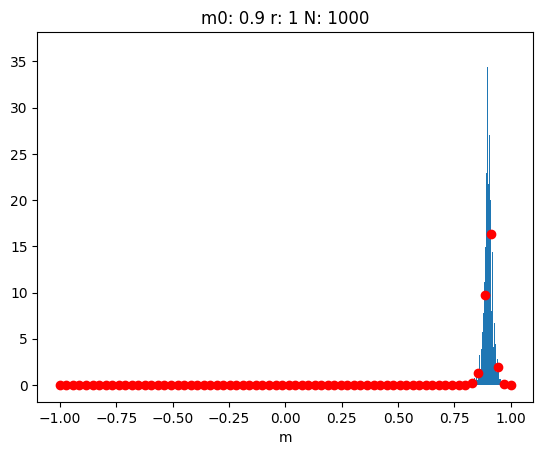

In [6]:
bins = 70
for m0 in [-0.8,-0.4,0.1,0.9]:
    for r in [0.01,0.1,1]:
        for N in [500, 1000]:
            clear_output(wait=True)
            print(f"m0: {m0} r: {r} N: {N}")
            plt.figure()
            plt.title(f"m0: {m0} r: {r} N: {N}")
            plt.xlabel("m")
            plt.hist(dist(N, 5*N, r, m0, 7500), bins = bins, density=True)        
            plt.scatter(np.linspace(-1,1,bins), sol.sol(N,r,m0,bins), color = "r")
            plt.savefig(f"../multi_check/figures/m0_{m0}_r_{r}_N_{N}.pdf")

# Time Evolution GIF

In [21]:
@njit
def voter_model_evolution_gif(N, t, r, m0, every):
    '''Takes:
    N: number of agents
    t: time in MC steps
    r: resetting rate per MC step
    every: time interval between frames
    
        Returns:
    mags: List of magnetisations at the different times '''

    config = init_config(N, m0)
    ini = config.copy()

    nframes = t // every + 1
    mags = np.zeros(nframes)

    mags[0] = mag(config)
    i = 1

    for ti in range(1, t + 1):
        for _ in range(N):
            if np.random.rand() < r:
                config = ini.copy()
                continue

            a = np.random.randint(0, N)
            b = np.random.randint(0, N)
            config[a] = config[b]

        if ti % every == 0:
            mags[i] = mag(config)
            i += 1

    return mags

@njit
def dist_gif(N, t, r, m0, samples, every):
    '''Returns the magnetisation at time t for some samples'''
    nframes = t // every + 1
    res = np.zeros((samples, nframes))

    for s in range(samples):
        res[s, :] = voter_model_evolution_gif(N, t, r, m0, every)

    return res

In [22]:
def make_compare_gif(
    filename,
    N,
    r,
    m0,
    samples,
    every,
    bins,
    t_max,
    ylim=None
):
    n_frames = int(t_max/every) + 1
    times = np.linspace(0, t_max, n_frames)
    # sim = dist_gif(N, t_max, r, m0, samples, every).T
    images = []

    for t in tqdm(times):
        p_th = sol.sol(N, r, m0, bins, t)
        p_sim = dist(N, t, r, m0, samples)

        fig, ax = plt.subplots(figsize=(6,4))
        ax.plot(np.linspace(-1,1,bins), p_th, lw=2)
        ax.hist(p_sim, bins = bins, density=True)
        ax.set_xlabel(r"$m$")
        ax.set_ylabel(r"$P(m,t)$")
        ax.set_title(rf"$t = {t:.2f}$")

        if ylim is not None:
            ax.set_ylim(*ylim)

        ax.grid(alpha=0.3)

        # Render to buffer
        fig.canvas.draw()
        image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
        image = image.reshape(fig.canvas.get_width_height()[::-1] + (3,))
        images.append(image)

        plt.close(fig)

    imageio.mimsave(filename, images, fps=12)

In [ ]:
make_compare_gif("../figures/voter_reset_theory_vs_sim.gif", 1000, 0.01, 0, 5000, 1, 71, 1000, ylim = (0,5))

# Good Figures

In [1]:
d = dist(1000, 1000, 0.01, 0.25, 10000)

NameError: name 'dist' is not defined

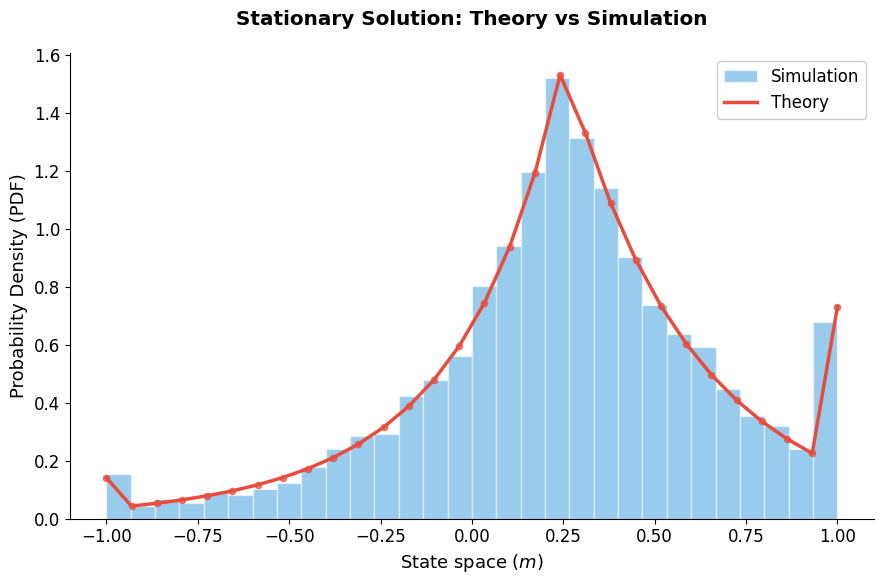

In [11]:
bins = 30
# Setting a professional style
# plt.style.use('seaborn-v0_8-muted') # or 'ggplot' / 'bmh'
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

# Setup the figure
fig, ax = plt.subplots(figsize=(9, 6), dpi=100)

# 1. Plot the Simulation (Histogram)
# Using a softer color and white edges for better separation
ax.hist(d, bins=bins, density=True, alpha=0.5, color='#3498db', 
        edgecolor='white', label="Simulation", zorder=2)

# 2. Plot the Theory (Scatter/Line)
# Calculate x-values for theory (ensuring they match the bin centers often looks better)
x_theory = np.linspace(-1, 1, bins)
y_theory = sol.sol(1000, 0.01, 0.25, bins)

ax.plot(x_theory, y_theory, color='#e74c3c', lw=2.5, 
        label="Theory", zorder=3)
ax.scatter(x_theory, y_theory, color='#e74c3c', s=20, alpha=0.7, zorder=4)

# 3. Aesthetics & Labels
ax.set_title("Stationary Solution: Theory vs Simulation", pad=20, fontweight='bold')
ax.set_xlabel("State space ($m$)", fontsize=13)
ax.set_ylabel("Probability Density (PDF)", fontsize=13)

# Remove top and right spines for a modern look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)



# Refined legend
ax.legend(frameon=True, facecolor='white', framealpha=1)

# Adjust layout and save
plt.tight_layout()
plt.savefig("../figures/theo_sim_del.pdf", bbox_inches='tight')
plt.show()